# Polymarket API EDA

This notebook documents the minimal data path needed for the project:

**Gamma API → market metadata and CLOB token IDs → CLOB API → historical market prices**

Our project studies sports markets on Polymarket and asks how sport-specific factors and market behaviour relate to predictive accuracy at different times before a market ends.

For now, the goal is:

1. Fetch market metadata from Gamma.
2. Parse the outcome/token mapping returned by Gamma.
3. Use a token ID from Gamma to request historical prices from the CLOB API.
4. Convert the result into a tidy time series that can later be joined with sports annotations and outcomes.


## 1. Setup

we use three libraries:

- `requests` for API calls
- `pandas` for tabular data
- `matplotlib` for a small sanity-check plot

Base URLs are defined as well

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import requests


GAMMA_BASE_URL = "https://gamma-api.polymarket.com"
CLOB_BASE_URL = "https://clob.polymarket.com"

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "CATS-Polymarket-Research/1.0"})


In [2]:
def get_json(base_url, endpoint, params=None, timeout=30):
    """Send a GET request and return the decoded JSON response."""
    response = SESSION.get(
        f"{base_url}{endpoint}",
        params=params,
        timeout=timeout,
    )
    response.raise_for_status()
    return response.json()


def parse_json_list(value):
    """Gamma sometimes returns list-like fields as JSON-encoded strings."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        return json.loads(value)
    return []


## 2. Gamma API: discover markets

Gamma is the metadata/discovery layer. It contains fields such as the market question, dates, outcome labels, volume/liquidity and CLOB token IDs to connect to the CLOB data.

In [3]:
gamma_params = {
    "limit": 100,
    "order": "volumeNum",
    "ascending": "false",
}

markets = get_json(
    GAMMA_BASE_URL,
    "/markets",
    params=gamma_params,
)

print(f"Markets returned: {len(markets)}")


Markets returned: 100


In [4]:
def market_to_record(market):
    outcomes = parse_json_list(market.get("outcomes"))
    token_ids = parse_json_list(market.get("clobTokenIds"))

    return {
        "gamma_market_id": market.get("id"),
        "condition_id": market.get("conditionId"),
        "question": market.get("question"),
        "slug": market.get("slug"),
        "start_date": market.get("startDate"),
        "end_date": market.get("endDate"),
        "closed": market.get("closed"),
        "volume": market.get("volumeNum"),
        "liquidity": market.get("liquidityNum"),
        "outcomes": outcomes,
        "clob_token_ids": token_ids,
    }


markets_df = pd.DataFrame(market_to_record(m) for m in markets)

markets_df.head()


,gamma_market_id,condition_id,question,slug,start_date,end_date,closed,volume,liquidity,outcomes,clob_token_ids
0,2063134,0x7d0aaf81bbd3fd73b6a1651cce08a452c0cbf9c0cbb4...,Will Adanech Abiebie be the next Prime Ministe...,will-adanech-abiebie-be-the-next-prime-ministe...,2026-04-27T21:55:14.576Z,2029-01-01T04:59:00Z,False,8.346003e+07,2.380153e+04,"[Yes, No]",[271469566528779445518777246903657450482896752...
1,665374,0x5db999fad322cea2914535aae5517060c3f80ad6d8c0...,Will the U.S. invade Iran before 2027?,will-the-us-invade-iran-before-2027,2025-11-05T17:52:17.414Z,2027-01-01T04:59:00Z,False,6.996801e+07,1.055412e+06,"[Yes, No]",[551150784210628855125391563037478030584076162...
2,703258,0x0b4cc3b739e1dfe5d73274740e7308b6fb389c5af040...,Will Jesus Christ return before 2027?,will-jesus-christ-return-before-2027,2025-11-25T18:08:21.296Z,2027-01-01T04:59:00Z,False,6.609563e+07,5.187657e+05,"[Yes, No]",[693243173550372714229439651413820950118719560...
3,2063135,0xb6d6f15a1b5d08753653f1867ccd6126badfbe182a75...,Will Gedion Timothewos be the next Prime Minis...,will-gedion-timothewos-be-the-next-prime-minis...,2026-04-27T21:55:15.894Z,2029-01-01T04:59:00Z,False,5.593823e+07,2.178609e+04,"[Yes, No]",[264852459612223135753739288186554980886137488...
4,561251,0x836b850fc838195374862551a36f1c8691d96ff01e58...,Will LeBron James win the 2028 US Presidential...,will-lebron-james-win-the-2028-us-presidential...,2025-07-11T19:06:10.755Z,2028-11-07T00:00:00Z,False,5.478220e+07,2.531597e+06,"[Yes, No]",[392233309663525134189077322394559489063998829...


### Outcome ↔ token mapping

`outcomes` and `clobTokenIds` are index-aligned. For example, if Gamma returns:

`outcomes = ["Yes", "No"]`

and

`clobTokenIds = ["TOKEN_A", "TOKEN_B"]`

then `TOKEN_A` is the CLOB token for **Yes** and `TOKEN_B` is the token for **No**.

This mapping is the bridge between the Gamma and CLOB APIs.


In [5]:
def outcome_token_map(market):
    outcomes = parse_json_list(market.get("outcomes"))
    token_ids = parse_json_list(market.get("clobTokenIds"))

    if len(outcomes) != len(token_ids):
        raise ValueError("Outcome labels and CLOB token IDs are not aligned.")

    return dict(zip(outcomes, token_ids))


sample_market = next(
    market
    for market in markets
    if parse_json_list(market.get("clobTokenIds"))
)

sample_token_map = outcome_token_map(sample_market)

print(sample_market["question"])
print(sample_token_map)


Will Adanech Abiebie be the next Prime Minister of Ethiopia?
{'Yes': '27146956652877944551877724690365745048289675287536243265951843487691050802191', 'No': '33216695217861742195941369663873573949679634432452142092545486849801915283392'}


## 3. CLOB API: historical prices

The CLOB API stores the trading-side market data. Its `/prices-history` endpoint takes a **CLOB token ID**, not the Gamma market ID or condition ID.

The token below therefore comes directly from the Gamma response above rather than being hard-coded.


In [6]:
# Most Polymarket markets are binary. Prefer the Yes token when available;
# otherwise use the first outcome so this example remains generic.
selected_outcome = (
    "Yes"
    if "Yes" in sample_token_map
    else next(iter(sample_token_map))
)

selected_token_id = sample_token_map[selected_outcome]

history_data = get_json(
    CLOB_BASE_URL,
    "/prices-history",
    params={
        "market": selected_token_id,
        "interval": "max",
        "fidelity": 60,  # minutes
    },
)

print(f"Outcome: {selected_outcome}")
print(f"Price observations: {len(history_data.get('history', []))}")


Outcome: Yes
Price observations: 741


In [7]:
history = pd.DataFrame(history_data.get("history", []))

if history.empty:
    raise ValueError("The selected token returned no price history.")

history = (
    history
    .rename(columns={"t": "timestamp", "p": "price"})
    .assign(
        datetime=lambda df: pd.to_datetime(
            df["timestamp"],
            unit="s",
            utc=True,
        ),
        price=lambda df: pd.to_numeric(df["price"], errors="coerce"),
    )
    .sort_values("datetime")
    .reset_index(drop=True)
)

history.head()


,timestamp,price,datetime
0,1787997636,0.006,2026-08-29 10:00:36+00:00
1,1788001217,0.006,2026-08-29 11:00:17+00:00
2,1788004827,0.006,2026-08-29 12:00:27+00:00
3,1788008417,0.006,2026-08-29 13:00:17+00:00
4,1788012017,0.006,2026-08-29 14:00:17+00:00


## 4. Put the time series in project terms

Our research question is interested in market accuracy at different horizons before a market ends. A useful first derived variable is therefore the time remaining until Gamma's `endDate`.


In [9]:
market_end = pd.to_datetime(
    sample_market.get("endDate"),
    utc=True,
    errors="coerce",
)

history["hours_to_market_end"] = (
    market_end - history["datetime"]
).dt.total_seconds() / 3600

history[
    ["datetime", "price", "hours_to_market_end"]
].tail()


,datetime,price,hours_to_market_end
736,2026-09-29 06:00:26+00:00,0.0025,19798.976111
737,2026-09-29 07:00:21+00:00,0.0025,19797.977500
738,2026-09-29 08:00:21+00:00,0.0025,19796.977500
739,2026-09-29 09:00:26+00:00,0.0025,19795.976111
740,2026-09-29 09:07:14+00:00,0.0025,19795.862778


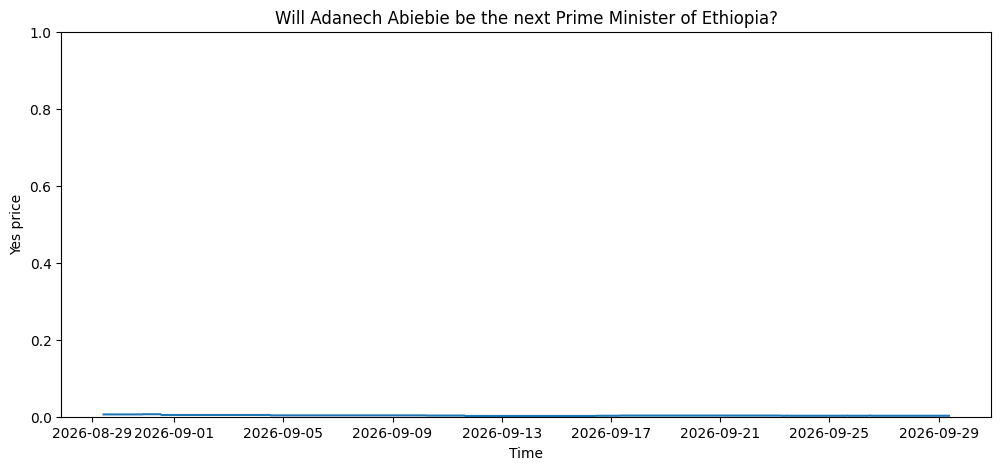

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(history["datetime"], history["price"])

plt.xlabel("Time")
plt.ylabel(f"{selected_outcome} price")
plt.title(sample_market["question"])
plt.ylim(0, 1)

plt.show()


## 5. What we need next

This notebook only establishes the API path. The actual data-collection pipeline should next add:

1. **Sports-market discovery and pagination** so we collect the complete relevant market universe rather than a 100-market sample.
2. **Resolved outcomes / labels** so predicted probabilities can be scored against what actually happened.
3. **Fixed pre-event horizons** such as 7 days, 24 hours, 6 hours and 1 hour before the relevant cutoff.
4. **Market-behaviour variables** such as volume, liquidity, spread and potentially trading activity.
5. **Manual sport annotations** such as sport/discipline, team vs. individual, ball involvement, team size, etc.
6. **Quality checks** for duplicated/related markets, missing histories, irregular timestamps and markets whose listed end time differs from the actual event or resolution time.